In [1]:
import jax.numpy as jnp
from typing import Tuple
from datasets import load_dataset
from jax.nn import one_hot

def load_mnist_data() -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """Load and preprocess MNIST dataset using Hugging Face datasets with JAX format."""
    print("Loading MNIST dataset from Hugging Face with JAX format...")
    
    # Load dataset from Hugging Face with JAX format
    mnist_dataset = load_dataset("mnist", cache_dir="~/.cache/huggingface/datasets").with_format("jax")
    
    # Extract train and test sets directly as JAX arrays
    train_data = mnist_dataset["train"]
    test_data = mnist_dataset["test"]
    
    # Extract images and reshape to 28x28
    x_train = jnp.array([img.reshape(28, 28) for img in train_data["image"]])
    y_train = jnp.array(train_data["label"])
    
    x_test = jnp.array([img.reshape(28, 28) for img in test_data["image"]])
    y_test = jnp.array(test_data["label"])
    
    # Normalize data
    x_train = x_train.astype(jnp.float32) / 255.0
    x_test = x_test.astype(jnp.float32) / 255.0
    
    # Convert labels to one-hot encoding
    y_train = one_hot(y_train, 10)
    y_test = one_hot(y_test, 10)
    
    print("x_train shape:", x_train.shape)
    print("y_train shape:", y_train.shape)
    print("x_test shape:", x_test.shape)
    print("y_test shape:", y_test.shape)
    
    return x_train, y_train, x_test, y_test
x_train, y_train, x_test, y_test = load_mnist_data()


/home/cwhy/Projects/Jax/picojam/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading MNIST dataset from Hugging Face with JAX format...
x_train shape: (60000, 28, 28)
y_train shape: (60000, 10)
x_test shape: (10000, 28, 28)
y_test shape: (10000, 10)


In [ ]:
import jax
import jax.numpy as jnp
from jax import jit, random
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec

def create_convergence_matrix(target_vector, epsilon=1e-6):
    """
    Create a matrix that, when repeatedly multiplied with a random vector,
    will converge to the target vector (implemented in JAX).
    
    Parameters:
    -----------
    target_vector : jnp.ndarray
        The vector we want the iterations to converge to
    epsilon : float
        Small constant to ensure numerical stability
        
    Returns:
    -----------
    jnp.ndarray
        A square matrix that will converge to the target vector upon repeated multiplication
    """
    # Normalize the target vector
    target = target_vector.flatten() / (jnp.linalg.norm(target_vector.flatten()) + epsilon)
    
    # Create the projection matrix: v * v^T / (v^T * v)
    # This is a rank-1 matrix with eigenvalue 1 in the direction of target
    projection_matrix = jnp.outer(target, target) / (jnp.dot(target, target) + epsilon)
    
    return projection_matrix

@jit
def matrix_multiply(matrix, vector):
    """
    JIT-compiled function to multiply matrix and vector
    """
    result = jnp.dot(matrix, vector)
    # Normalize to prevent numerical issues
    norm = jnp.linalg.norm(result)
    return jnp.where(norm > 0, result / norm, result)


def create_animation(matrix, target_image, iterations=30, num_random_vectors=3, seed=42):
    """
    Create an animation showing the convergence of random vectors to the target image.
    
    Parameters:
    -----------
    matrix : jnp.ndarray
        The convergence matrix
    target_image : jnp.ndarray
        The target MNIST digit image
    iterations : int
        Number of iterations to perform
    num_random_vectors : int
        Number of random vectors to test
    seed : int
        Random seed for reproducibility
    
    Returns:
    --------
    matplotlib.animation.Animation
        Animation showing the convergence process
    """
    key = random.PRNGKey(seed)
    n = matrix.shape[0]
    
    # Generate random vectors
    random_vectors = []
    for i in range(num_random_vectors):
        key, subkey = random.split(key)
        initial_vector = random.normal(subkey, (n,))
        initial_vector = initial_vector / jnp.linalg.norm(initial_vector)
        random_vectors.append(initial_vector)
    
    # Compute the evolution of each vector
    vector_evolutions = []
    for initial_vector in random_vectors:
        evolution = [np.array(initial_vector)]
        current = initial_vector
        
        for i in range(iterations):
            current = matrix_multiply(matrix, current)
            evolution.append(np.array(current))
            
        vector_evolutions.append(evolution)
    
    # Create the figure and axes for the animation
    fig = plt.figure(figsize=(14, 10))
    
    # Create a 2x4 grid to accommodate all vectors
    gs = GridSpec(2, 4, width_ratios=[1, 1, 1, 1], height_ratios=[1, 1])
    
    # Target image display
    ax_target = fig.add_subplot(gs[0, 0])
    ax_target.imshow(np.array(target_image), cmap='gray')
    ax_target.set_title("Target MNIST Digit")
    ax_target.axis('off')
    
    # Convergence matrix display
    ax_matrix = fig.add_subplot(gs[1, 0])
    matrix_slice = np.array(matrix).reshape(28, 28, 28, 28)[:, 14, :, 14]  # Middle slice
    matrix_img = ax_matrix.imshow(matrix_slice, cmap='viridis', aspect='auto')
    plt.colorbar(matrix_img, ax=ax_matrix)
    ax_matrix.set_title("Convergence Matrix (Middle Slice)")
    ax_matrix.axis('off')
    
    # Random vector evolution display - put each in its own cell
    axes_vectors = []
    positions = [(0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3)][:num_random_vectors]
    
    for i, pos in enumerate(positions):
        ax = fig.add_subplot(gs[pos])
        axes_vectors.append(ax)
        ax.set_title(f"Random Vector {i+1}")
        ax.axis('off')
    
    # Function to update the figure at each frame
    def update(frame):
        for i, ax in enumerate(axes_vectors):
            ax.clear()
            ax.imshow(vector_evolutions[i][frame].reshape(28, 28), cmap='gray')
            ax.set_title(f"Random Vector {i+1}, Iteration {frame}")
            ax.axis('off')
        return axes_vectors
    
    # Create the animation
    anim = animation.FuncAnimation(fig, update, frames=iterations+1, interval=200, blit=False)
    plt.tight_layout()
    
    return anim




def display_still_frames(matrix, target_image, iterations=30, num_vectors=3, seed=42):
    """Display still frames of the convergence process at specific iterations"""
    key = random.PRNGKey(seed)
    n = matrix.shape[0]
    
    # Create the figure
    fig = plt.figure(figsize=(15, 4 * num_vectors))
    
    # Show target image
    ax = plt.subplot(num_vectors, 4, 1)
    ax.imshow(np.array(target_image), cmap='gray')
    ax.set_title("Target Digit")
    ax.axis('off')
    
    # Show a slice of the matrix
    ax = plt.subplot(num_vectors, 4, 2)
    matrix_slice = np.array(matrix).reshape(28, 28, 28, 28)
    matrix_slice = matrix_slice[:, 14, :, 14]  # Take middle slice
    im = ax.imshow(matrix_slice, cmap='viridis')
    plt.colorbar(im, ax=ax)
    ax.set_title("Convergence Matrix\n(Middle Slice)")
    ax.axis('off')
    
    # For each random vector
    for v in range(num_vectors):
        key, subkey = random.split(key)
        initial_vector = random.normal(subkey, (n,))
        initial_vector = initial_vector / jnp.linalg.norm(initial_vector)
        
        # Compute iterations
        current = initial_vector
        states = [np.array(current)]
        for i in range(iterations):
            current = matrix_multiply(matrix, current)
            if i == 4 or i == 14 or i == iterations-1:
                states.append(np.array(current))
        
        # Plot initial state
        ax = plt.subplot(num_vectors, 4, v*4 + 1)
        ax.imshow(states[0].reshape(28, 28), cmap='gray')
        ax.set_title(f"Vector {v+1}: Initial")
        ax.axis('off')
        
        # Plot intermediate states
        ax = plt.subplot(num_vectors, 4, v*4 + 2)
        ax.imshow(states[1].reshape(28, 28), cmap='gray')
        ax.set_title(f"After 5 iterations")
        ax.axis('off')
        
        ax = plt.subplot(num_vectors, 4, v*4 + 3)
        ax.imshow(states[2].reshape(28, 28), cmap='gray')
        ax.set_title(f"After 15 iterations")
        ax.axis('off')
        
        # Plot final state
        ax = plt.subplot(num_vectors, 4, v*4 + 4)
        ax.imshow(states[3].reshape(28, 28), cmap='gray')
        ax.set_title(f"After {iterations} iterations")
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('mnist_convergence_frames.png', dpi=150)
    plt.show()


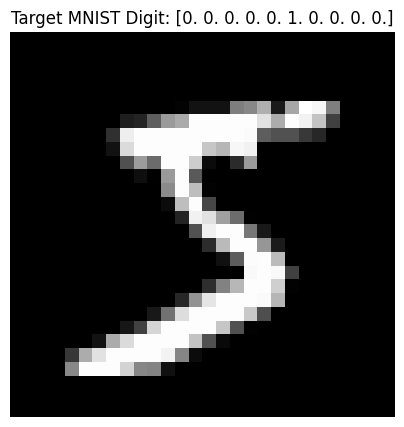

Testing convergence with random vectors...
Computing eigenvalues of convergence matrix...
Top 5 eigenvalues (magnitude): [2.2847205e-08 2.2847205e-08 4.4282562e-08 4.4282562e-08 9.9999911e-01]


In [13]:
    
target_image = x_train[0]  # Target image
target_digit = y_train[0]  # Target digit

# Create the convergence matrix
convergence_matrix = create_convergence_matrix(target_image)

# Display the target image
plt.figure(figsize=(5, 5))
plt.imshow(np.array(target_image), cmap='gray')
plt.title(f"Target MNIST Digit: {target_digit}")
plt.axis('off')
plt.show()

print("Testing convergence with random vectors...")

# Test the convergence properties
# test_convergence(convergence_matrix, iterations=30, num_tests=3)

# Additional analysis: compute and print the top eigenvalues
print("Computing eigenvalues of convergence matrix...")
eigenvalues = jnp.linalg.eigvals(convergence_matrix)
top_eigenvalues = jnp.sort(jnp.abs(eigenvalues))[-5:]

print(f"Top 5 eigenvalues (magnitude): {top_eigenvalues}")

# Create and save the animation
# anim = create_animation(convergence_matrix, target_image, iterations=30, num_random_vectors=3)

    
# # Save the animation as an MP4 file
# writer = animation.FFMpegWriter(fps=5, metadata=dict(artist='Me'), bitrate=1800)
# anim.save('mnist_convergence.mp4', writer=writer)

# print("Animation saved as 'mnist_convergence.mp4'")

# # Also display a still image for each step
# display_still_frames(convergence_matrix, target_image)